# Features Extraction Code

This notebook loads the study data and computes stroke and image features

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import nan, atan, cos
import json
from pathlib import Path
import pandas as pd
import cv2
import re
from collections import Counter
import base64
import os
from scipy.ndimage import gaussian_filter1d
from dotenv import load_dotenv
import openai

load_dotenv()
client = openai.OpenAI(api_key=os.getenv("API_KEY"), base_url=os.getenv("BASE_URL"))

## Only use the first x seconds

Sets a variable that allows features to be calculated based on the first $x$ seconds only to test how stable the analysis is based on length of the raw data

In [3]:
# How many seconds to include (-1 = use the entire sample)
SECONDS_CUTOFF = -1

# Which suffix to use for the filenames
SUFFIX = ""

## Some helper classes and functions

In [4]:
emotions = {
    'EXCITEMENT': 1,
    'CONTENTMENT': 2,
    'ANGER': 3,
    'SADNESS': 4,
    'NEUTRAL': 5,
}

emotions_r = {
    1: 'EXCITEMENT',
    2: 'CONTENTMENT',
    3: 'ANGER',
    4: 'SADNESS',
    5: 'NEUTRAL',
}

handedness = {
    'L': 1,
    'R': 2,
    'B': 3,
}

gender = {
    'F': 1,
    'M': 2,
    'D': 3,
}

class Stroke:
    def __init__(self, x, y, pressure, pen_color=None, pen_size=None, timestamps=None, tilt_x=None, tilt_y=None):
        self.x = np.array(x)
        self.y = np.array(y)
        self.pressure = np.array(pressure, dtype=float)

        point_count = len(self.x)

        if tilt_x is None:
            tilt_x = [np.nan] * point_count
        if tilt_y is None:
            tilt_y = [np.nan] * point_count
        self.tilt_x = np.array(tilt_x, dtype=float)
        self.tilt_y = np.array(tilt_y, dtype=float)

        self.pen_color = tuple(pen_color) if pen_color is not None else None
        self.pen_size = pen_size
        self.timestamps = np.array(
            timestamps if timestamps is not None else [])


def print_metadata(participant):
    round_summary = ['strokes', 'undone_strokes', 'eraser_strokes']
    
    round_items = [
        'net_erased_pixels',
        'mood_start',
        'mood_end',
        'emotion',
        'round_id',
        'participant_id',
        'session_number',
        'round_index',
        'round_total',
        'emotion_name',
        'session_type',
        'arousal_first',
        'completion_status',
        'drawing_duration_seconds',
        'saved_at',
    ]

    metadata_items = [
        "participant_id",
        "session_number",
        "session_type",
        "baseline_mood",
        "emotion_order",
        "arousal_first",
        "language",
        "saved_at",
    ]
    metadata = participant['metadata']
    rounds = list(participant['data'].values())
    for item in metadata_items:
        print(f"{item}: {metadata[item]}")
        
    for i, round in enumerate(rounds):
        print(f"Round {i}") # the rounds are sorted by emotion, not time
        for item in round_summary:
            print(f"\t{item}: {len(round[item])}")
        for item in round_items:
            print(f"\t{item}: {round[item]}")

## Conversion factor from pixel -> cm
## The wacom tablet has a diagonal of 13.3in, a resolution of 1080p and is a 16/9 display
## 1in = 2.54cm
FACTOR_PIXEL_TO_CM = cos(atan(16/9)) * 13.3 * 2.54 / 1080
MAX_PRESSURE = 2**12
MAX_TILT = 2**6
def convert_strokes(strokes, cutoff=None):
    stroke_list = []
        
    for stroke in strokes:
        if cutoff and stroke['timestamps'][-1] > cutoff:
            if stroke['timestamps'][0] > cutoff:
                continue
            
            valid_samples = np.sum(stroke['timestamps'] <= cutoff)
            stroke['x'] = stroke['x'][:valid_samples]
            stroke['y'] = stroke['y'][:valid_samples]
            stroke['pressure'] = stroke['pressure'][:valid_samples]
            stroke['timestamps'] = stroke['timestamps'][:valid_samples]
            stroke['tilt_x'] = stroke['tilt_x'][:valid_samples]
            stroke['tilt_y'] = stroke['tilt_y'][:valid_samples]
        stroke_list.append(Stroke(stroke['x'] * FACTOR_PIXEL_TO_CM, stroke['y'] * FACTOR_PIXEL_TO_CM, stroke['pressure'] / MAX_PRESSURE, stroke['pen_color'], stroke['pen_size'], stroke['timestamps'], stroke['tilt_x'] / MAX_TILT, stroke['tilt_y'] / MAX_TILT))
    
    return stroke_list

def display_pressure(stroke_list):
    press = []
    time = []
    tilt_x = []
    tilt_y = []
    for stroke in stroke_list:
        press += list(stroke.pressure) + [nan]
        tilt_x += list(stroke.tilt_x) + [nan]
        tilt_y += list(stroke.tilt_y) + [nan]
        time += list(stroke.timestamps) + [nan]
    _, ax = plt.subplots()
    ax.plot(time, press, label="pressure", c="black")
    ax.plot(time, tilt_x, label="x-tilt", c="blue")
    ax.plot(time, tilt_y, label="y-tilt", c="red")
    ax.legend()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("value [0-1]")
    plt.show()
    
def concat(list_list):
    ls = []
    for l in list_list:
        ls += l
    return ls

def find_duplicate_strokes(active, erased, undone):
    strokes = set()
    for stroke in active + erased  + undone:
        t = stroke.timestamps[0]
        if t in strokes:
            print("duplicate found!!")
        strokes.add(t)

## Loading the data

Assumed folder structure:

```
data_adults
|___participants.csv
|___<ID1>
|  |___drawings
|     |___<round1>.png
|     |___<round2>.png
|     |___<round3>.png
|  |___session_metadata.json
|  |___<round1>.npz
|  |___<round2>.npz
|  |___<round3>.npz
|___<ID2>
|  |___ ...
...
```

In [5]:
data = {}
metadata = pd.read_csv("data_adults/participants.csv")
print(metadata)
for number, id in enumerate(metadata['id']):
    id_low = id.lower()
    base_path = Path("data_adults") / id_low / "session_0"
    if not base_path.exists():
        raise Exception(f"Participant with ID {id_low} does not exist!")
    
    converted_data = []
    for file in base_path.glob("*.npz"):
        raw_data = np.load(file, allow_pickle=True)
        data_dict = {key: raw_data[key] for key in raw_data.files}
        cutoff = None if SECONDS_CUTOFF == -1 else SECONDS_CUTOFF
        data_dict['strokes'] =        convert_strokes(data_dict['strokes'], cutoff=cutoff)
        data_dict['undone_strokes'] = convert_strokes(data_dict['undone_strokes'], cutoff=cutoff)
        data_dict['eraser_strokes'] = convert_strokes(data_dict['eraser_strokes'], cutoff=cutoff)
        
        all_strokes = data_dict['strokes'] + data_dict["eraser_strokes"] + data_dict["undone_strokes"]
        all_strokes.sort(key=lambda s: s.timestamps[0])
        data_dict['all_strokes'] = all_strokes
        converted_data.append(data_dict)
    for file in base_path.glob("*.json"): # there should only be one
        session_metadata = json.loads(file.read_text(encoding='utf-8'))
        emo = session_metadata['emotion_order'] # get emotions as numbers
        assigned_data = {}
        for i, emotion in enumerate(emo):
            image_path = None
            for image in (base_path / "drawings").glob("*.png"):
                if emotion.lower() in image.name:
                    image_path = image.absolute()
                    break
            # read image and remove the blue border
            converted_data[i]['image'] = cv2.imread(image_path)[5:-5, 5:-5]
                    
            assigned_data[emotions[emotion]] = converted_data[i]
        data[id_low] = {'metadata': session_metadata,
                        'data': assigned_data, 
                        'age': metadata.loc[number]['age'],
                        'gender': gender[metadata.loc[number]['gender']],
                        'handedness': handedness[metadata.loc[number]['handedness']]}
participants = list(data.keys())
participants

      id  age gender handedness
0   KADD   22      M          R
1   ONXU   24      M          R
2   HNBA   23      M          L
3   AAGI   25      M          R
4   JMZV   28      F          R
5   FEON   23      M          R
6   BUJD   25      F          R
7   VUPQ   24      M          R
8   JYDT   33      M          R
9   RQNT   23      M          R
10  BYVO   22      M          R
11  FBEQ   22      M          R
12  JSHJ   23      F          R
13  ODJN   22      M          L
14  MTAP   22      M          R
15  FJXQ   19      F          R
16  THOR   19      F          R
17  JFYL   22      F          R
18  JTAB   22      M          R
19  OYZC   22      M          R
20  NLIZ   22      M          R
21  TGFV   22      M          L
22  BTAC   25      M          L
23  GTUQ   23      M          R
24  HXXX   23      M          R


['kadd',
 'onxu',
 'hnba',
 'aagi',
 'jmzv',
 'feon',
 'bujd',
 'vupq',
 'jydt',
 'rqnt',
 'byvo',
 'fbeq',
 'jshj',
 'odjn',
 'mtap',
 'fjxq',
 'thor',
 'jfyl',
 'jtab',
 'oyzc',
 'nliz',
 'tgfv',
 'btac',
 'gtuq',
 'hxxx']

Just to make sure everything is saved correctly

participant_id: aagi
session_number: 0
session_type: adult
baseline_mood: {'valence': 0.4362745098039216, 'arousal': -0.6356209150326797}
emotion_order: ['SADNESS', 'NEUTRAL', 'CONTENTMENT']
arousal_first: False
language: en
saved_at: 2026-07-02T16:13:20
Round 0
	strokes: 72
	undone_strokes: 5
	eraser_strokes: 1
	net_erased_pixels: 3248
	mood_start: [-0.62908497  0.71732026]
	mood_end: [-0.63562092  0.2745098 ]
	emotion: 4
	round_id: session0_sadness_2026-07-02_16-13-33
	participant_id: aagi
	session_number: 0
	round_index: 1
	round_total: 3
	emotion_name: SADNESS
	session_type: adult
	arousal_first: False
	completion_status: time_expired_save
	drawing_duration_seconds: 300.1492118835449
	saved_at: 2026-07-02T16:21:57
Round 1
	strokes: 160
	undone_strokes: 5
	eraser_strokes: 0
	net_erased_pixels: 544
	mood_start: [0.21895425 0.40849673]
	mood_end: [ 0.46732026 -0.4869281 ]
	emotion: 2
	round_id: session0_contentment_2026-07-02_16-30-54
	participant_id: aagi
	session_number: 0
	round_in

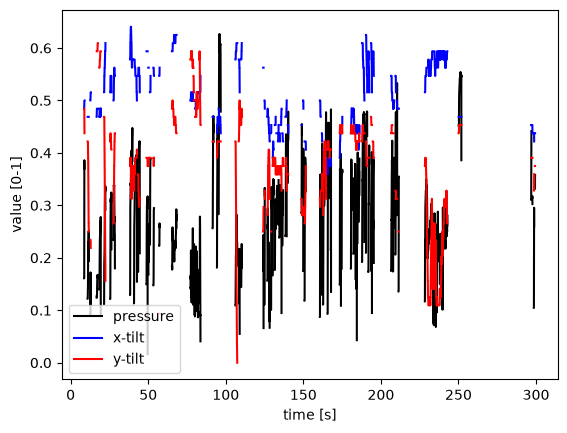

In [6]:
print_metadata(data['aagi'])
display_pressure(data['aagi']['data'][4]['all_strokes'])

for participant,values in data.items():
    rounds = list(values['data'].values())
    for round in rounds:
        # print(data_dict)
        find_duplicate_strokes(round['strokes'], round['undone_strokes'], round['eraser_strokes'])


## Dataframe creation

We create the dataframe and input the data we already have

In [7]:
feature_names = ["participant_id", "age", "gender", "handedness", "val_baseline", "ar_baseline",
                  "round", "emotion", "emotion_name", "erased_pixels", 
                 "drawing_time", "val_start", "ar_start", 
                 "val_end", "ar_end", "n_strokes", 
                 "n_undone_strokes", "n_eraser_strokes",
                 ]
round_data = [{}, {}, {}]
for participant,values in data.items():
    features = []
    features.append(participant)
    features.append(values['age'])
    features.append(values['gender'])
    features.append(values['handedness'])
    features.append(values['metadata']['baseline_mood']['valence'])
    features.append(values['metadata']['baseline_mood']['arousal'])
    rounds = list(values['data'].values())
    for round in rounds:
        index = int(round['round_index'])
        ls = features.copy()
        ls.append(index)
        ls.append(round['emotion'])
        ls.append(round['emotion_name'])
        ls.append(round['net_erased_pixels'])
        ls.append(round['drawing_duration_seconds'])
        ls.append(round['mood_start'][0])
        ls.append(round['mood_start'][1])
        ls.append(round['mood_end'][0])
        ls.append(round['mood_end'][1])
        ls.append(len(round['strokes']))
        ls.append(len(round['undone_strokes']))
        ls.append(len(round['eraser_strokes']))
        round_data[index-1][participant + str(index)] = ls
    
df_data = round_data[0]
df_data.update(round_data[1])
df_data.update(round_data[2])

df = pd.DataFrame(df_data, index=feature_names).transpose()
df

,participant_id,age,gender,handedness,val_baseline,ar_baseline,round,emotion,emotion_name,erased_pixels,drawing_time,val_start,ar_start,val_end,ar_end,n_strokes,n_undone_strokes,n_eraser_strokes
kadd1,kadd,22,2,2,0.230392,-0.630719,1,1,EXCITEMENT,2925,300.1441869735718,0.519608,0.212418,0.189542,-0.20915,84,1,0
onxu1,onxu,24,2,2,0.638889,0.183007,1,2,CONTENTMENT,17127,280.17847657203674,-0.014706,-0.328431,0.29085,-0.560458,136,0,15
hnba1,hnba,23,2,1,1.0,0.661765,1,3,ANGER,52003,182.02278399467468,1.0,0.576797,0.594771,0.441176,75,21,0
aagi1,aagi,25,2,2,0.436275,-0.635621,1,4,SADNESS,3248,300.1492118835449,-0.629085,0.71732,-0.635621,0.27451,72,5,1
jmzv1,jmzv,28,1,2,0.143791,0.308824,1,5,NEUTRAL,51998,271.10864186286926,0.220588,-0.197712,0.410131,-0.349673,117,23,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nliz3,nliz,22,2,2,0.547386,-0.568627,3,1,EXCITEMENT,48026,227.3283360004425,0.589869,-0.263072,0.616013,-0.116013,48,18,1
tgfv3,tgfv,22,2,1,0.45915,0.364379,3,2,CONTENTMENT,255356,300.24877762794495,0.418301,0.418301,0.374183,0.22549,14,7,3
btac3,btac,25,2,1,0.240196,-0.575163,3,5,NEUTRAL,1760,125.39113855361938,0.058824,-0.246732,0.065359,-0.485294,36,2,0
gtuq3,gtuq,23,2,2,0.398693,0.075163,3,3,ANGER,1333,158.59528851509094,-0.171569,0.117647,-0.05719,0.261438,36,0,1


## Some statistics

In [22]:
total = df.shape[0] // 3

n_women = df[df["gender"] == 1].shape[0] // 3
n_men = df[df["gender"] == 2].shape[0] // 3
n_nb = df[df["gender"] == 3].shape[0] // 3
print(f"gender:\t\tF:M:X -- {n_women}:{n_men}:{n_nb} -- female percentage: ({n_women / total * 100:0.2f}%)")

n_l = df[df["handedness"] == 1].shape[0] // 3
n_r = df[df["handedness"] == 2].shape[0] // 3
n_b = df[df["handedness"] == 3].shape[0] // 3
print(f"handedness:\tL:R:B -- {n_l}:{n_r}:{n_b} -- left handedness: ({n_l / total * 100:0.2f}%)")

for i in range(5):
    n_emotion = df[df["emotion"] == i+1].shape[0]
    print(f"Number of {emotions_r[i+1]} rounds: {n_emotion}")

gender:		F:M:X -- 6:19:0 -- female percentage: (24.00%)
handedness:	L:R:B -- 4:21:0 -- left handedness: (16.00%)
Number of EXCITEMENT rounds: 13
Number of CONTENTMENT rounds: 12
Number of ANGER rounds: 12
Number of SADNESS rounds: 13
Number of NEUTRAL rounds: 25


## Stroke Features

### Stroke dynamics

In [23]:
def get_stroke_dynamics(stroke: Stroke):
    x = stroke.x
    y = stroke.y
    t = stroke.timestamps

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)

    # avoid division by zero
    dt[dt == 0] = np.nan

    # distance between consecutive points
    distance = np.sqrt(dx**2 + dy**2)

    # stroke length
    stroke_length = np.nansum(distance)

    # speed
    speed = distance / dt
    stroke_speed = np.nanmean(speed)

    # acceleration (only if computable)
    if len(speed) >= 2:
        acceleration = np.diff(speed) / dt[1:]
        stroke_accel = np.nanmean(acceleration)
    else:
        stroke_accel = np.nan

    return stroke_length, stroke_speed, stroke_accel

In [24]:
stroke_total_length_list = [[], [], []]
stroke_mean_length_list  = [[], [], []]
stroke_std_length_list   = [[], [], []]
stroke_mean_speed_list   = [[], [], []]
stroke_std_speed_list    = [[], [], []]
stroke_mean_accel_list   = [[], [], []]
stroke_std_accel_list    = [[], [], []]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1

        # Extract length of each stroke of participant
        stroke_length_array = []
        stroke_speed_array = []
        stroke_accel_array = []
        for stroke in round['all_strokes']:
            stroke_length, stroke_speed, stroke_accel = get_stroke_dynamics(stroke)
            stroke_length_array.append(stroke_length)
            stroke_speed_array.append(stroke_speed)
            stroke_accel_array.append(stroke_accel)

        # Compute total stroke length, and mean/std of stroke length, speed, acceleration
        stroke_total_length_list[index].append(np.nansum(stroke_length_array))
        stroke_mean_length_list [index].append(np.nanmean(stroke_length_array))
        stroke_std_length_list  [index].append(np.nanstd(stroke_length_array))
        stroke_mean_speed_list  [index].append(np.nanmean(stroke_speed_array))
        stroke_std_speed_list   [index].append(np.nanstd(stroke_speed_array))
        stroke_mean_accel_list  [index].append(np.nanmean(stroke_accel_array))
        stroke_std_accel_list   [index].append(np.nanstd(stroke_accel_array))

df[f"stroke_total_length"] = concat(stroke_total_length_list)
df[f"stroke_mean_length"]  = concat(stroke_mean_length_list)
df[f"stroke_std_length"]   = concat(stroke_std_length_list)
df[f"stroke_mean_speed"]   = concat(stroke_mean_speed_list)
df[f"stroke_std_speed"]    = concat(stroke_std_speed_list)
df[f"stroke_mean_accel"]   = concat(stroke_mean_accel_list)
df[f"stroke_std_accel"]    = concat(stroke_std_accel_list)

### Stroke pressure dynamics

In [10]:
stroke_mean_pressure_list  = [[], [], []]
stroke_std_pressure_list   = [[], [], []]
stroke_pressure_slope_list = [[], [], []]

for participant,values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1
        
        all_strokes = round['all_strokes']
        all_strokes.sort(key=lambda s: s.timestamps[0])
        stroke_pressure_array = [np.nanmean(stroke.pressure) for stroke in all_strokes]
        stroke_pressure_array = np.array(stroke_pressure_array)
        
        # mean / std
        stroke_mean_pressure_list[index].append(np.nanmean(stroke_pressure_array))
        stroke_std_pressure_list [index].append(np.nanstd(stroke_pressure_array))

        # artificial time axis
        t = np.arange(len(stroke_pressure_array))

        # slope via linear regression
        if len(stroke_pressure_array) >= 2:
            slope, _ = np.polyfit(t, stroke_pressure_array, 1)
        else:
            slope = np.nan

        stroke_pressure_slope_list[index].append(slope)

df[f"stroke_mean_pressure"] =  concat(stroke_mean_pressure_list)
df[f"stroke_std_pressure"] =   concat(stroke_std_pressure_list)
df[f"stroke_pressure_slope"] = concat(stroke_pressure_slope_list)

### Stroke width

In [11]:
pen_size_used_count_list = [[],[],[]]
mean_pen_size_list =       [[],[],[]]
std_pen_size_list =        [[],[],[]]

for participant,values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1
        
        pen_size_array = [stroke.pen_size for stroke in (round['all_strokes'])]

        pen_size_used_count_list[index].append(len(set(pen_size_array)))
        mean_pen_size_list      [index].append(np.mean(pen_size_array))
        std_pen_size_list       [index].append(np.std(pen_size_array))


df[f"pen_size_used_count"] = concat(pen_size_used_count_list)
df[f"pen_size_mean"] =       concat(mean_pen_size_list)
df[f"pen_size_std"] =        concat(std_pen_size_list)

### Stroke complexity

In [12]:
def compute_stroke_complexity(stroke):
    x = stroke.x
    y = stroke.y

    dx = np.diff(x)
    dy = np.diff(y)

    # Compute stroke length for later normalization
    segment_lengths = np.sqrt(dx**2 + dy**2)
    stroke_length = np.sum(segment_lengths)

    # compute turning angles
    angles = []

    for i in range(len(dx) - 1):

        v1 = np.array([dx[i], dy[i]])
        v2 = np.array([dx[i+1], dy[i+1]])

        norm1 = np.linalg.norm(v1)
        norm2 = np.linalg.norm(v2)

        if norm1 == 0 or norm2 == 0:
            continue

        cos_angle = np.dot(v1, v2) / (norm1 * norm2)
        cos_angle = np.clip(cos_angle, -1, 1)

        angle = np.arccos(cos_angle)
        angles.append(angle)

    angles = np.array(angles)

    avg_curvature = np.nanmean(angles) if len(angles) > 0 else np.nan
    angularity_index = np.nansum(angles) / stroke_length if stroke_length > 0 else np.nan

    return avg_curvature, angularity_index

In [13]:
stroke_curvature_list =  [[],[],[]]
stroke_angularity_list = [[],[],[]]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1

        curvature_values = []
        angularity_values = []
        for stroke in (round['all_strokes']):
            curvature, angularity = compute_stroke_complexity(stroke)
            curvature_values.append(curvature)
            angularity_values.append(angularity)

        stroke_curvature_list [index].append(np.nanmean(curvature_values))
        stroke_angularity_list[index].append(np.nanmean(angularity_values))

df[f"stroke_mean_curvature"] =  concat(stroke_curvature_list)
df[f"stroke_mean_angularity"] = concat(stroke_angularity_list)

### Temporal drawing behavior

In [14]:
avg_time_between_strokes_list = [[],[],[]]
std_time_between_strokes_list = [[],[],[]]
total_pause_time_list =         [[],[],[]]

for participant,values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1

        all_strokes = round['all_strokes'] # strokes are sorted by timestamp

        # get start and end times of each stroke
        start_times = [stroke.timestamps[0] for stroke in all_strokes]
        end_times = [stroke.timestamps[-1] for stroke in all_strokes]
        # compute pauses between strokes
        pauses = []
        for i in range(len(all_strokes) - 1):
            pause = start_times[i+1] - end_times[i]
            pauses.append(pause)

        pauses = np.array(pauses)

        total_pause = np.nansum(pauses)
        avg_pause = np.nanmean(pauses)
        std_pause = np.nanstd(pauses)

        total_pause_time_list        [index].append(total_pause)
        avg_time_between_strokes_list[index].append(avg_pause)
        std_time_between_strokes_list[index].append(std_pause)


df[f"avg_time_between_strokes"] = concat(avg_time_between_strokes_list)
df[f"std_time_between_strokes"] = concat(std_time_between_strokes_list)
df[f"total_pause_time"] =         concat(total_pause_time_list)
df[f"pause_ratio"]      = df[f"total_pause_time"]   / df[f"drawing_time"]
df[f"stroke_frequency"] = (df[f"n_strokes"] + df[f"n_eraser_strokes"]) / df[f"drawing_time"]

### Stroke jerk & movement smoothness

Jerk (derivative of acceleration) captures how erratic/abrupt the motion is. Smoother strokes have lower jerk. We also count velocity zero-crossings (direction-of-speed-change reversals), a common smoothness/tremor proxy in motor-control literature.

In [15]:
def get_stroke_jerk(stroke: Stroke):
    x = stroke.x
    y = stroke.y
    t = stroke.timestamps

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)
    dt[dt == 0] = np.nan

    distance = np.sqrt(dx**2 + dy**2)
    speed = distance / dt

    if len(speed) < 2:
        return np.nan, np.nan

    accel = np.diff(speed) / dt[1:]

    if len(accel) < 2:
        return np.nan, np.nan

    dt2 = dt[2:].copy()
    dt2[dt2 == 0] = np.nan
    jerk = np.diff(accel) / dt2

    # mean absolute jerk (magnitude of erraticism) and its variability
    return np.nanmean(np.abs(jerk)), np.nanstd(jerk)


def get_speed_zero_crossing_rate(stroke: Stroke):
    """Number of local speed reversals (accelerating <-> decelerating) per second.
    Higher values indicate less smooth, more tremor-like movement."""
    x = stroke.x
    y = stroke.y
    t = stroke.timestamps

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)
    dt[dt == 0] = np.nan

    speed = np.sqrt(dx**2 + dy**2) / dt
    if len(speed) < 3:
        return np.nan

    d_speed = np.diff(speed)
    d_speed = d_speed[~np.isnan(d_speed)]
    if len(d_speed) < 2:
        return np.nan

    signs = np.sign(d_speed)
    signs = signs[signs != 0]
    if len(signs) < 2:
        return 0.0

    crossings = np.sum(np.diff(signs) != 0)
    duration = t[-1] - t[0] if len(t) > 0 else np.nan
    return crossings / duration if duration else np.nan

In [16]:
stroke_mean_abs_jerk_list = [[], [], []]
stroke_std_jerk_list      = [[], [], []]
stroke_zero_cross_list    = [[], [], []]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1

        jerk_array = []
        zero_cross_array = []
        for stroke in round['all_strokes']:
            mean_abs_jerk, std_jerk = get_stroke_jerk(stroke)
            jerk_array.append(mean_abs_jerk)
            zero_cross_array.append(get_speed_zero_crossing_rate(stroke))

        stroke_mean_abs_jerk_list[index].append(np.nanmean(jerk_array))
        stroke_std_jerk_list     [index].append(np.nanmean([j for j in jerk_array if not np.isnan(j)]) if False else np.nanmean(jerk_array))
        stroke_zero_cross_list   [index].append(np.nanmean(zero_cross_array))

df["stroke_mean_abs_jerk"]        = concat(stroke_mean_abs_jerk_list)
df["stroke_speed_zero_cross_rate"] = concat(stroke_zero_cross_list)

### Pressure-velocity coupling

Does the participant press harder when moving faster (or slower)? This correlation can differ by arousal state, e.g. tense/high-arousal drawing may show pressure spikes independent of speed, while relaxed drawing may show a more consistent coupling.

In [17]:
def get_pressure_velocity_corr(stroke: Stroke):
    x = stroke.x
    y = stroke.y
    t = stroke.timestamps
    p = stroke.pressure

    dx = np.diff(x)
    dy = np.diff(y)
    dt = np.diff(t)
    dt[dt == 0] = np.nan

    speed = np.sqrt(dx**2 + dy**2) / dt
    p_mid = (p[:-1] + p[1:]) / 2  # pressure at the midpoint of each segment

    mask = ~np.isnan(speed) & ~np.isnan(p_mid)
    if mask.sum() < 2 or np.std(speed[mask]) == 0 or np.std(p_mid[mask]) == 0:
        return np.nan

    return np.corrcoef(speed[mask], p_mid[mask])[0, 1]

In [18]:
pressure_velocity_corr_list = [[], [], []]

for participant, values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1

        corrs = [get_pressure_velocity_corr(stroke) for stroke in round['all_strokes']]
        pressure_velocity_corr_list[index].append(np.nanmean(corrs))

df["pressure_velocity_corr"] = concat(pressure_velocity_corr_list)

### Tilt-based features

Pen-grip angle and its variability can reflect hand tension. We also check whether tilt co-varies with pressure (a stable grip vs. a shifting one).

In [19]:
def get_tilt_features(stroke: Stroke):
    tilt_x = stroke.tilt_x
    tilt_y = stroke.tilt_y
    pressure = stroke.pressure

    mean_tilt_x = np.nanmean(tilt_x)
    mean_tilt_y = np.nanmean(tilt_y)
    std_tilt_x = np.nanstd(tilt_x)
    std_tilt_y = np.nanstd(tilt_y)

    mask = ~np.isnan(tilt_x) & ~np.isnan(pressure)
    if mask.sum() >= 2 and np.std(tilt_x[mask]) > 0 and np.std(pressure[mask]) > 0:
        tilt_pressure_corr = np.corrcoef(tilt_x[mask], pressure[mask])[0, 1]
    else:
        tilt_pressure_corr = np.nan

    return mean_tilt_x, mean_tilt_y, std_tilt_x, std_tilt_y, tilt_pressure_corr

In [20]:
mean_tilt_x_list =       [[], [], []]
mean_tilt_y_list =       [[], [], []]
std_tilt_x_list =        [[], [], []]
std_tilt_y_list =        [[], [], []]
tilt_pressure_corr_list = [[], [], []]

for participant, values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1

        mtx, mty, stx, sty, tpc = [], [], [], [], []
        for stroke in round['all_strokes']:
            a, b, c, d, e = get_tilt_features(stroke)
            mtx.append(a); mty.append(b); stx.append(c); sty.append(d); tpc.append(e)

        mean_tilt_x_list       [index].append(np.nanmean(mtx))
        mean_tilt_y_list       [index].append(np.nanmean(mty))
        std_tilt_x_list        [index].append(np.nanmean(stx))
        std_tilt_y_list        [index].append(np.nanmean(sty))
        tilt_pressure_corr_list[index].append(np.nanmean(tpc))

df["tilt_x_mean"] = concat(mean_tilt_x_list)
df["tilt_y_mean"] = concat(mean_tilt_y_list)
df["tilt_x_std"]  = concat(std_tilt_x_list)
df["tilt_y_std"]  = concat(std_tilt_y_list)
df["tilt_pressure_corr"] = concat(tilt_pressure_corr_list)

### Stroke straightness

Ratio of straight-line displacement to actual path length per stroke. A value near 1 means the stroke is nearly a straight line; low values mean it meanders.

In [21]:
def get_stroke_straightness(stroke: Stroke):
    x = stroke.x
    y = stroke.y

    dx = np.diff(x)
    dy = np.diff(y)
    path_length = np.nansum(np.sqrt(dx**2 + dy**2))
    displacement = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)

    if path_length == 0:
        return np.nan

    return displacement / path_length

In [1]:
stroke_mean_straightness_list = [[], [], []]
stroke_std_straightness_list  = [[], [], []]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1

        straightness_array = [get_stroke_straightness(stroke) for stroke in round['all_strokes']]

        stroke_mean_straightness_list[index].append(np.nanmean(straightness_array))
        stroke_std_straightness_list [index].append(np.nanstd(straightness_array))

df["stroke_mean_straightness"] = concat(stroke_mean_straightness_list)
df["stroke_std_straightness"]  = concat(stroke_std_straightness_list)

NameError: name 'participants' is not defined

### Spatial / global drawing features

How much of the canvas is used, how spread out the drawing is, and where it's centered. Larger bounding box / spread can relate to higher arousal or more expansive/expressive drawing; off-center or compressed drawings may relate to withdrawal.

In [23]:
def get_spatial_features(all_strokes):
    xs_list = [st.x for st in all_strokes if len(st.x) > 0]
    ys_list = [st.y for st in all_strokes if len(st.y) > 0]

    if len(xs_list) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    xs = np.concatenate(xs_list)
    ys = np.concatenate(ys_list)

    bbox_w = xs.max() - xs.min()
    bbox_h = ys.max() - ys.min()
    bbox_area = bbox_w * bbox_h

    centroid_x = xs.mean()
    centroid_y = ys.mean()
    spatial_spread = np.sqrt(np.var(xs) + np.var(ys))  # overall dispersion around centroid

    return bbox_w, bbox_h, bbox_area, centroid_x, centroid_y, spatial_spread

In [ ]:
bbox_w_list =    [[], [], []]
bbox_h_list =    [[], [], []]
bbox_area_list = [[], [], []]
centroid_x_list = [[], [], []]
centroid_y_list = [[], [], []]
spatial_spread_list = [[], [], []]

for participant, values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1

        # only "active" strokes represent the final drawing's coverage
        w, h, area, cx, cy, spread = get_spatial_features(round['strokes'])

        bbox_w_list        [index].append(w)
        bbox_h_list        [index].append(h)
        bbox_area_list     [index].append(area)
        centroid_x_list    [index].append(cx)
        centroid_y_list    [index].append(cy)
        spatial_spread_list[index].append(spread)

df["bbox_width"]     = concat(bbox_w_list)
df["bbox_height"]    = concat(bbox_h_list)
df["bbox_area"]      = concat(bbox_area_list)
df["centroid_x"]     = concat(centroid_x_list)
df["centroid_y"]     = concat(centroid_y_list)
df["spatial_spread"] = concat(spatial_spread_list)

# ink coverage relative to the area actually used (fills bbox vs sparse scribbles)
df["ink_density"] = df["stroke_total_length"] / df["bbox_area"]

### Signal regularity: entropy & spectral features

Sample entropy on the per-round speed signal captures how predictable/regular the movement is (low entropy = repetitive/regular, high entropy = erratic/complex). The dominant-frequency features capture rhythmic or tremor-like components in the movement, similar to measures used in motor-control research.

In [25]:
def sample_entropy(sig, m=2, r_factor=0.2):
    """Sample entropy of a 1D signal. Lower = more regular/predictable, higher = more complex/erratic."""
    sig = np.asarray(sig)
    sig = sig[~np.isnan(sig)]
    n = len(sig)
    if n < m + 2:
        return np.nan

    r = r_factor * np.std(sig)
    if r == 0:
        return np.nan

    def _count(m):
        templates = np.array([sig[i:i + m] for i in range(n - m + 1)])
        count = 0
        for i in range(len(templates)):
            dist = np.max(np.abs(templates - templates[i]), axis=1)
            count += np.sum(dist <= r) - 1  # exclude self-match
        return count

    B = _count(m)
    A = _count(m + 1)
    if B == 0 or A == 0:
        return np.nan

    return -np.log(A / B)


def dominant_frequency(sig, t):
    """Dominant frequency (Hz) and its relative power in a (possibly non-uniformly sampled) signal.
    Uses the mean sampling rate as an approximation since our sampling isn't perfectly uniform."""
    sig = np.asarray(sig)
    t = np.asarray(t)
    mask = ~np.isnan(sig)
    sig, t = sig[mask], t[mask]

    if len(sig) < 8:
        return np.nan, np.nan

    duration = t[-1] - t[0]
    if duration <= 0:
        return np.nan, np.nan

    fs = len(sig) / duration
    sig_centered = sig - np.mean(sig)

    freqs = np.fft.rfftfreq(len(sig_centered), d=1 / fs)
    power = np.abs(np.fft.rfft(sig_centered)) ** 2

    if len(power) <= 1:
        return np.nan, np.nan

    idx = np.argmax(power[1:]) + 1  # skip DC component
    relative_power = power[idx] / np.sum(power[1:])

    return freqs[idx], relative_power


def get_round_speed_signal(all_strokes):
    """Concatenate per-stroke speed values (with NaN gaps between strokes) into one signal for the round."""
    speeds = []
    times = []
    for stroke in all_strokes:
        x, y, t = stroke.x, stroke.y, stroke.timestamps
        if len(x) < 2:
            continue
        dx, dy, dt = np.diff(x), np.diff(y), np.diff(t)
        dt[dt == 0] = np.nan
        speed = np.sqrt(dx**2 + dy**2) / dt
        speeds.extend(speed.tolist())
        times.extend(t[1:].tolist())
    return np.array(speeds), np.array(times)

In [26]:
speed_entropy_list =    [[], [], []]
dominant_freq_list =    [[], [], []]
dominant_freq_power_list = [[], [], []]

for participant, values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1

        speed_sig, speed_t = get_round_speed_signal(round['all_strokes'])

        # speed_entropy_list[index].append(sample_entropy(speed_sig))

        freq, power = dominant_frequency(speed_sig, speed_t)
        dominant_freq_list      [index].append(freq)
        dominant_freq_power_list[index].append(power)

# df["speed_sample_entropy"]   = concat(speed_entropy_list)
df["speed_dominant_freq"]    = concat(dominant_freq_list)
df["speed_dominant_freq_power"] = concat(dominant_freq_power_list)

# NOTE: sample_entropy as implemented here is O(n^2) per round; for very long strokes/rounds
# consider subsampling the speed signal or using an optimized library (e.g. antropy / nolds) if this is slow.

### Within-round progression / trend features

Do speed, stroke length, or pressure systematically increase or decrease over the course of a round? This can capture fatigue, escalation, or calming across the drawing session (analogous to what's already done for `stroke_pressure_slope`).

In [27]:
def linear_trend(values):
    values = np.asarray(values, dtype=float)
    mask = ~np.isnan(values)
    if mask.sum() < 2:
        return np.nan
    t = np.arange(len(values))[mask]
    slope, _ = np.polyfit(t, values[mask], 1)
    return slope


def first_second_half_diff(values):
    """Mean of second half minus mean of first half — positive = increasing over the round."""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.nan
    mid = len(values) // 2
    first_half = values[:mid] if mid > 0 else values[:1]
    second_half = values[mid:]
    return np.nanmean(second_half) - np.nanmean(first_half)

In [28]:
speed_trend_list =        [[], [], []]
speed_half_diff_list =    [[], [], []]
length_trend_list =       [[], [], []]
length_half_diff_list =   [[], [], []]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1

        stroke_speeds = []
        stroke_lengths = []
        for stroke in round['all_strokes']:
            length, speed, _ = get_stroke_dynamics(stroke)
            stroke_speeds.append(speed)
            stroke_lengths.append(length)

        speed_trend_list     [index].append(linear_trend(stroke_speeds))
        speed_half_diff_list [index].append(first_second_half_diff(stroke_speeds))
        length_trend_list    [index].append(linear_trend(stroke_lengths))
        length_half_diff_list[index].append(first_second_half_diff(stroke_lengths))

df["stroke_speed_trend"]        = concat(speed_trend_list)
df["stroke_speed_half_diff"]    = concat(speed_half_diff_list)
df["stroke_length_trend"]       = concat(length_trend_list)
df["stroke_length_half_diff"]   = concat(length_half_diff_list)

### Additional Features

if we release this notebook distribute these analyses where they actually belong

In [29]:
# ------------------------------------------------------------
# 1. Round-level pressure-change-speed and tilt-change-speed
#    signals (analogous to your existing get_round_speed_signal)
# ------------------------------------------------------------

def get_round_pressure_change_signal(all_strokes):
    """Concatenate per-stroke speed-of-pressure-change values
    (with implicit gaps between strokes) into one signal for the round."""
    changes = []
    times = []
    for stroke in all_strokes:
        p, t = stroke.pressure, stroke.timestamps
        if len(p) < 2:
            continue
        dp = np.diff(p)
        dt = np.diff(t)
        dt[dt == 0] = np.nan
        speed_of_change = dp / dt
        changes.extend(speed_of_change.tolist())
        times.extend(t[1:].tolist())
    return np.array(changes), np.array(times)


def get_round_tilt_change_signal(all_strokes, axis="x"):
    """Concatenate per-stroke speed-of-tilt-change values for the
    given axis ('x' or 'y') into one signal for the round."""
    changes = []
    times = []
    for stroke in all_strokes:
        tilt = stroke.tilt_x if axis == "x" else stroke.tilt_y
        t = stroke.timestamps
        if len(tilt) < 2:
            continue
        dtilt = np.diff(tilt)
        dt = np.diff(t)
        dt[dt == 0] = np.nan
        speed_of_change = dtilt / dt
        changes.extend(speed_of_change.tolist())
        times.extend(t[1:].tolist())
    return np.array(changes), np.array(times)


# ------------------------------------------------------------
# 2. Full-spectrum helper (returns freqs + power, not just the
#    dominant peak) so we can compute bandwidth/median/distance
# ------------------------------------------------------------

def compute_spectrum(sig, t):
    """Returns (freqs, power) for a (possibly non-uniformly sampled)
    signal, using the mean sampling rate as an approximation.
    Skips the DC component. Returns (None, None) if signal too short."""
    sig = np.asarray(sig)
    t = np.asarray(t)
    mask = ~np.isnan(sig) & ~np.isnan(t)
    sig, t = sig[mask], t[mask]

    if len(sig) < 8:
        return None, None

    duration = t[-1] - t[0]
    if duration <= 0:
        return None, None

    fs = len(sig) / duration
    sig_centered = sig - np.mean(sig)

    freqs = np.fft.rfftfreq(len(sig_centered), d=1 / fs)
    power = np.abs(np.fft.rfft(sig_centered)) ** 2

    # drop DC component (index 0)
    return freqs[1:], power[1:]


def spectral_bandwidth_90(freqs, power):
    """Range of frequencies covering the central 90% of spectral
    density (i.e., the 5th-to-95th percentile band of the power
    distribution over frequency). Lower = more concentrated/regular
    movement; higher = more spread-out/erratic frequency content."""
    if freqs is None or len(freqs) == 0 or np.sum(power) == 0:
        return np.nan

    cumulative = np.cumsum(power) / np.sum(power)
    f_low = freqs[np.searchsorted(cumulative, 0.05)]
    f_high = freqs[np.searchsorted(cumulative, 0.95)]
    return f_high - f_low


def spectral_weighted_median(freqs, power):
    """Frequency at which cumulative power reaches 50% — i.e., the
    power-weighted median frequency. Higher = more high-frequency
    content present (shakier/less smooth movement)."""
    if freqs is None or len(freqs) == 0 or np.sum(power) == 0:
        return np.nan

    cumulative = np.cumsum(power) / np.sum(power)
    idx = np.searchsorted(cumulative, 0.5)
    idx = min(idx, len(freqs) - 1)
    return freqs[idx]


def spectral_distance_to_mean(freqs, power, mean_freqs, mean_power):
    """Euclidean distance between this round's normalized power
    spectrum and the population-mean spectrum (interpolated onto a
    common frequency grid). Higher = more atypical/idiosyncratic
    frequency content relative to the sample."""
    if freqs is None or len(freqs) == 0 or np.sum(power) == 0:
        return np.nan
    if mean_freqs is None or len(mean_freqs) == 0:
        return np.nan

    power_norm = power / np.sum(power)
    mean_power_norm = mean_power / np.sum(mean_power)

    # interpolate this round's spectrum onto the population's freq grid
    interp_power = np.interp(mean_freqs, freqs, power_norm, left=0, right=0)

    return np.sqrt(np.sum((interp_power - mean_power_norm) ** 2))


# ------------------------------------------------------------
# 3. Peak-counting (smoothness/tremor proxy): count local
#    maxima+minima of a Gaussian-smoothed signal, normalized by
#    duration — analogous to Asselborn et al.'s "peaks per second"
# ------------------------------------------------------------

def count_signal_peaks_per_second(sig, t, sigma=2):
    """Number of local extrema (maxima + minima) per second in a
    Gaussian-smoothed signal. Higher = more oscillatory/erratic."""
    sig = np.asarray(sig)
    t = np.asarray(t)
    mask = ~np.isnan(sig) & ~np.isnan(t)
    sig, t = sig[mask], t[mask]

    if len(sig) < 5:
        return np.nan

    smoothed = gaussian_filter1d(sig, sigma=sigma)
    d = np.diff(smoothed)
    signs = np.sign(d)
    signs = signs[signs != 0]
    if len(signs) < 2:
        return 0.0

    n_peaks = np.sum(np.diff(signs) != 0)
    duration = t[-1] - t[0]
    return n_peaks / duration if duration > 0 else np.nan

def box_counting_fractal_dimension(x, y, n_scales=10, min_box_frac=0.01, max_box_frac=0.5):
    """
    Estimates the box-counting (Minkowski-Bouligand) fractal dimension
    of a 2D point set (the pen-tip trajectory for a round).

    Returns np.nan if there are too few points or the trajectory has
    zero spatial extent.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    if len(x) < 20:
        return np.nan

    x_range = x.max() - x.min()
    y_range = y.max() - y.min()
    extent = max(x_range, y_range)
    if extent == 0:
        return np.nan

    # box sizes on a log scale, from a small fraction to a large fraction
    # of the drawing's spatial extent
    box_sizes = np.logspace(
        np.log10(min_box_frac * extent),
        np.log10(max_box_frac * extent),
        n_scales
    )

    counts = []
    for box_size in box_sizes:
        # assign each point to a box via floor division, count occupied boxes
        box_x = np.floor((x - x.min()) / box_size).astype(int)
        box_y = np.floor((y - y.min()) / box_size).astype(int)
        occupied_boxes = set(zip(box_x, box_y))
        counts.append(len(occupied_boxes))

    counts = np.array(counts)
    valid = counts > 0
    if valid.sum() < 3:
        return np.nan

    # fractal dimension = -slope of log(count) vs log(box_size)
    log_sizes = np.log(box_sizes[valid])
    log_counts = np.log(counts[valid])
    slope, _ = np.polyfit(log_sizes, log_counts, 1)

    return -slope


In [30]:
# ============================================================
# Extraction loop — pass 1: compute per-round signals + dominant
# frequency features, and cache the raw (freqs, power) spectra
# for the population-mean step below.
# ============================================================

pressure_change_bandwidth_list =  [[], [], []]
pressure_change_median_list =     [[], [], []]
pressure_change_peaks_list =      [[], [], []]

tiltx_change_bandwidth_list =     [[], [], []]
tiltx_change_median_list =        [[], [], []]
tiltx_change_peaks_list =         [[], [], []]

tilty_change_bandwidth_list =     [[], [], []]
tilty_change_median_list =        [[], [], []]
tilty_change_peaks_list =         [[], [], []]

speed_peaks_list =                [[], [], []]

fractal_dim_list = [[], [], []]

# caches for the population-mean-distance step (pass 2)
pressure_change_spectra_cache = []  # list of (participant, index, freqs, power)
tiltx_change_spectra_cache =    []
tilty_change_spectra_cache =    []
speed_spectra_cache =            []

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1
        all_strokes = round['all_strokes']

        pc_sig, pc_t = get_round_pressure_change_signal(all_strokes)
        pc_freqs, pc_power = compute_spectrum(pc_sig, pc_t)
        pressure_change_bandwidth_list[index].append(spectral_bandwidth_90(pc_freqs, pc_power))
        pressure_change_median_list[index].append(spectral_weighted_median(pc_freqs, pc_power))
        pressure_change_peaks_list[index].append(count_signal_peaks_per_second(pc_sig, pc_t))
        pressure_change_spectra_cache.append((participant, index, pc_freqs, pc_power))

        tx_sig, tx_t = get_round_tilt_change_signal(all_strokes, axis="x")
        tx_freqs, tx_power = compute_spectrum(tx_sig, tx_t)
        tiltx_change_bandwidth_list[index].append(spectral_bandwidth_90(tx_freqs, tx_power))
        tiltx_change_median_list[index].append(spectral_weighted_median(tx_freqs, tx_power))
        tiltx_change_peaks_list[index].append(count_signal_peaks_per_second(tx_sig, tx_t))
        tiltx_change_spectra_cache.append((participant, index, tx_freqs, tx_power))

        ty_sig, ty_t = get_round_tilt_change_signal(all_strokes, axis="y")
        ty_freqs, ty_power = compute_spectrum(ty_sig, ty_t)
        tilty_change_bandwidth_list[index].append(spectral_bandwidth_90(ty_freqs, ty_power))
        tilty_change_median_list[index].append(spectral_weighted_median(ty_freqs, ty_power))
        tilty_change_peaks_list[index].append(count_signal_peaks_per_second(ty_sig, ty_t))
        tilty_change_spectra_cache.append((participant, index, ty_freqs, ty_power))

        speed_sig, speed_t = get_round_speed_signal(all_strokes)
        speed_peaks_list[index].append(count_signal_peaks_per_second(speed_sig, speed_t))
        speed_freqs, speed_power = compute_spectrum(speed_sig, speed_t)
        speed_spectra_cache.append((participant, index, speed_freqs, speed_power))

        # use "active" strokes (final drawing), consistent with your
        # existing get_spatial_features usage
        xs_list = [st.x for st in round['strokes'] if len(st.x) > 0]
        ys_list = [st.y for st in round['strokes'] if len(st.y) > 0]

        if len(xs_list) == 0:
            fractal_dim_list[index].append(np.nan)
            continue

        xs = np.concatenate(xs_list)
        ys = np.concatenate(ys_list)

        fd = box_counting_fractal_dimension(xs, ys)
        fractal_dim_list[index].append(fd)



# ============================================================
# Pass 2: compute population-mean spectrum and per-round distance
# to it, for each of the four signal types
# ============================================================

def compute_distance_to_mean_feature(spectra_cache, n_rounds_per_participant=3):
    valid = [(p, i, f, pw) for (p, i, f, pw) in spectra_cache if f is not None and len(f) > 0]
    if len(valid) == 0:
        return [[np.nan] * 0 for _ in range(n_rounds_per_participant)]

    # common frequency grid: use the finest-resolution valid spectrum's freqs
    max_len = max(len(f) for (_, _, f, _) in valid)
    ref_freqs = max((f for (_, _, f, _) in valid), key=len)

    # interpolate every spectrum onto ref_freqs, normalize, and average
    interp_powers = []
    for (_, _, f, pw) in valid:
        pw_norm = pw / np.sum(pw) if np.sum(pw) > 0 else pw
        interp = np.interp(ref_freqs, f, pw_norm, left=0, right=0)
        interp_powers.append(interp)
    mean_power = np.mean(interp_powers, axis=0)

    # now compute each round's distance to this mean, preserving order
    distance_list = [[], [], []]
    cache_by_order = spectra_cache  # already in participant/round iteration order
    for (participant, index, f, pw) in cache_by_order:
        d = spectral_distance_to_mean(f, pw, ref_freqs, mean_power)
        distance_list[index].append(d)

    return distance_list


pressure_change_distance_list = compute_distance_to_mean_feature(pressure_change_spectra_cache)
tiltx_change_distance_list =    compute_distance_to_mean_feature(tiltx_change_spectra_cache)
tilty_change_distance_list =    compute_distance_to_mean_feature(tilty_change_spectra_cache)
speed_distance_list =           compute_distance_to_mean_feature(speed_spectra_cache)

df["pressure_change_bandwidth"] = concat(pressure_change_bandwidth_list)
df["pressure_change_median_freq"] = concat(pressure_change_median_list)
df["pressure_change_peaks_per_sec"] = concat(pressure_change_peaks_list)
df["pressure_change_distance_to_mean"] = concat(pressure_change_distance_list)

df["tiltx_change_bandwidth"] = concat(tiltx_change_bandwidth_list)
df["tiltx_change_median_freq"] = concat(tiltx_change_median_list)
df["tiltx_change_peaks_per_sec"] = concat(tiltx_change_peaks_list)
df["tiltx_change_distance_to_mean"] = concat(tiltx_change_distance_list)

df["tilty_change_bandwidth"] = concat(tilty_change_bandwidth_list)
df["tilty_change_median_freq"] = concat(tilty_change_median_list)
df["tilty_change_peaks_per_sec"] = concat(tilty_change_peaks_list)
df["tilty_change_distance_to_mean"] = concat(tilty_change_distance_list)

df["speed_peaks_per_sec"] = concat(speed_peaks_list)
df["speed_distance_to_mean"] = concat(speed_distance_list)

df["trajectory_fractal_dimension"] = concat(fractal_dim_list)

In [31]:
def get_tilt_magnitude_angle(stroke: Stroke):
    tilt_x = stroke.tilt_x
    tilt_y = stroke.tilt_y

    magnitude = np.sqrt(tilt_x**2 + tilt_y**2)
    angle = np.arctan2(tilt_y, tilt_x)  # radians, [-pi, pi]

    mean_magnitude = np.nanmean(magnitude)
    std_magnitude = np.nanstd(magnitude)

    # circular mean for angle (avoids wraparound artifacts near +-pi)
    mask = ~np.isnan(angle)
    if mask.sum() > 0:
        mean_angle = np.arctan2(np.nanmean(np.sin(angle[mask])),
                                 np.nanmean(np.cos(angle[mask])))
    else:
        mean_angle = np.nan

    return mean_magnitude, std_magnitude, mean_angle


In [32]:
tilt_magnitude_mean_list = [[], [], []]
tilt_magnitude_std_list  = [[], [], []]
tilt_angle_mean_list     = [[], [], []]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1

        mags, stds, angles = [], [], []
        for stroke in round['all_strokes']:
            m, s, a = get_tilt_magnitude_angle(stroke)
            mags.append(m); stds.append(s); angles.append(a)

        tilt_magnitude_mean_list[index].append(np.nanmean(mags))
        tilt_magnitude_std_list [index].append(np.nanmean(stds))

        # circular mean across strokes for the round-level angle
        valid_angles = [a for a in angles if not np.isnan(a)]
        if valid_angles:
            round_angle = np.arctan2(np.mean(np.sin(valid_angles)),
                                      np.mean(np.cos(valid_angles)))
        else:
            round_angle = np.nan
        tilt_angle_mean_list[index].append(round_angle)

df["tilt_magnitude_mean"] = concat(tilt_magnitude_mean_list)
df["tilt_magnitude_std"]  = concat(tilt_magnitude_std_list)
df["tilt_angle_mean"]     = concat(tilt_angle_mean_list)


# --- tilt trend across the round (mirrors your existing stroke_pressure_slope pattern) ---

tiltx_trend_list = [[], [], []]
tilty_trend_list = [[], [], []]

for participant, values in data.items():
    for round in values['data'].values():
        index = int(round['round_index']) - 1

        all_strokes = round['all_strokes']
        all_strokes.sort(key=lambda s: s.timestamps[0])

        tiltx_per_stroke = [np.nanmean(stroke.tilt_x) for stroke in all_strokes]
        tilty_per_stroke = [np.nanmean(stroke.tilt_y) for stroke in all_strokes]

        t = np.arange(len(tiltx_per_stroke))

        if len(tiltx_per_stroke) >= 2:
            slope_x, _ = np.polyfit(t, tiltx_per_stroke, 1)
            slope_y, _ = np.polyfit(t, tilty_per_stroke, 1)
        else:
            slope_x, slope_y = np.nan, np.nan

        tiltx_trend_list[index].append(slope_x)
        tilty_trend_list[index].append(slope_y)

df["tiltx_trend"] = concat(tiltx_trend_list)
df["tilty_trend"] = concat(tilty_trend_list)


# --- straightness trend across the round (mirrors stroke_speed_trend pattern) ---

straightness_trend_list = [[], [], []]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1

        straightness_array = [get_stroke_straightness(stroke) for stroke in round['all_strokes']]
        straightness_trend_list[index].append(linear_trend(straightness_array))

df["stroke_straightness_trend"] = concat(straightness_trend_list)


df["bbox_aspect_ratio"] = df["bbox_width"] / df["bbox_height"]
df["bbox_diagonal"] = np.sqrt(df["bbox_width"]**2 + df["bbox_height"]**2)
df["bbox_elongation"] = (
    (df["bbox_width"] - df["bbox_height"]).abs() /
    (df["bbox_width"] + df["bbox_height"])
)

## Image Features

### Spacial Coverage

In [33]:
def extract_spatial_features(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # drawing mask (non-white pixels)
    mask = np.any(image != [255,255,255], axis=2)

    H, W = mask.shape

    # coordinates of non-white pixels
    ys, xs = np.where(mask)

    # no drawing case
    if len(xs) == 0:
        return [np.nan]*6

    # Coverage ratio
    coverage_ratio = len(xs) / (H * W)

    # Horizontal dispersion
    pixel_std_x = np.std(xs) / W

    # Vertical dispersion
    pixel_std_y = np.std(ys) / H

    # Average distance to center
    center_x = W / 2
    center_y = H / 2

    dist = np.sqrt((xs - center_x)**2 + (ys - center_y)**2)
    avg_distance_center = np.mean(dist) / 0.5*np.sqrt(W**2 + H**2)

    # Left-right balance
    left_mass = np.sum(xs < center_x)
    right_mass = np.sum(xs >= center_x)

    lr_balance = (left_mass - right_mass) / (left_mass + right_mass)

    # Top-bottom balance
    top_mass = np.sum(ys < center_y)
    bottom_mass = np.sum(ys >= center_y)

    tb_balance = (top_mass - bottom_mass) / (top_mass + bottom_mass)

    return [
        coverage_ratio,
        pixel_std_x,
        pixel_std_y,
        avg_distance_center,
        lr_balance,
        tb_balance
    ]

In [34]:
coverage_list =     [[],[],[]]
std_x_list =        [[],[],[]]
std_y_list =        [[],[],[]]
center_dist_list =  [[],[],[]]
lr_balance_list =   [[],[],[]]
tb_balance_list =   [[],[],[]]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1
        img = round['image']

        features = extract_spatial_features(img)

        coverage_list   [index].append(features[0])
        std_x_list      [index].append(features[1])
        std_y_list      [index].append(features[2])
        center_dist_list[index].append(features[3])
        lr_balance_list [index].append(features[4])
        tb_balance_list [index].append(features[5])
        
        
df["surface_coverage_ratio"] = concat(coverage_list)
df["pixel_std_x"] =            concat(std_x_list)
df["pixel_std_y"] =            concat(std_y_list)
df["mean_distance_center"] =   concat(center_dist_list)
df["left_right_balance"] =     concat(lr_balance_list)
df["top_bottom_balance"] =     concat(tb_balance_list)

### Color Analysis

In [35]:
def extract_color_features(img):

    # remove white background
    mask = ~((img[:,:,0] == 255) &
             (img[:,:,1] == 255) &
             (img[:,:,2] == 255))

    stroke_pixels = img[mask]

    if len(stroke_pixels) == 0:
        return [np.nan]*9

    # number of different colors
    unique_colors = np.unique(stroke_pixels, axis=0)
    n_colors = len(unique_colors)

    # convert stroke pixels to HSV
    hsv_pixels = cv2.cvtColor(stroke_pixels.reshape(-1,1,3), cv2.COLOR_BGR2HSV).reshape(-1,3)

    hue = hsv_pixels[:,0].astype(float)       # [0, 180]
    sat = hsv_pixels[:,1].astype(float) / 255 # [0, 1]
    val = hsv_pixels[:,2].astype(float) / 255 # [0, 1]

    # circular mean for hue
    angles = hue * 2*np.pi / 180

    mean_angle = np.arctan2(np.mean(np.sin(angles)),
                            np.mean(np.cos(angles)))

    avg_hue = (mean_angle * 180 / np.pi) % 180

    std_hue = np.std(hue)

    avg_sat = np.mean(sat)
    std_sat = np.std(sat)

    avg_val = np.mean(val)
    std_val = np.std(val)

    # black vs others
    black_pixels = np.sum((stroke_pixels[:,0] == 0) &
                          (stroke_pixels[:,1] == 0) &
                          (stroke_pixels[:,2] == 0))
    black_ratio = black_pixels / len(stroke_pixels)

    # warm vs cool classification
    # red / orange / yellow → warm
    # green / blue / purple → cool
    # Warm:   0–30  OR  150–179
    # Cool:   30–150
    warm_mask = (hue < 30) | (hue > 150)
    cool_mask = (hue >= 30) & (hue <= 150)

    warm_pixels = np.sum(warm_mask)
    cool_pixels = np.sum(cool_mask)

    warm_cool_ratio = warm_pixels / (cool_pixels + 1e-8)

    return (
        n_colors,
        avg_hue, std_hue,
        avg_sat, std_sat,
        avg_val, std_val,
        black_ratio,
        warm_cool_ratio
    )
    
def extract_brightness_range(img):
    mask = ~((img[:,:,0] == 255) & (img[:,:,1] == 255) & (img[:,:,2] == 255))
    stroke_pixels = img[mask]
    if len(stroke_pixels) == 0:
        return np.nan
    hsv_pixels = cv2.cvtColor(stroke_pixels.reshape(-1,1,3), cv2.COLOR_BGR2HSV).reshape(-1,3)
    val = hsv_pixels[:,2].astype(float) / 255
    # 5th-95th percentile range, more robust to outlier pixels than raw max-min
    return np.percentile(val, 95) - np.percentile(val, 5)

In [ ]:
color_count_list =     [[],[],[]]
avg_hue_list =         [[],[],[]]
std_hue_list =         [[],[],[]]
avg_sat_list =         [[],[],[]]
std_sat_list =         [[],[],[]]
avg_val_list =         [[],[],[]]
std_val_list =         [[],[],[]]
black_ratio_list =     [[],[],[]]
warm_cool_ratio_list = [[],[],[]]
brightness_range_list = [[], [], []]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1
        img = round['image']

        features = extract_color_features(img)

        color_count_list    [index].append(features[0])
        avg_hue_list        [index].append(features[1])
        std_hue_list        [index].append(features[2])
        avg_sat_list        [index].append(features[3])
        std_sat_list        [index].append(features[4])
        avg_val_list        [index].append(features[5])
        std_val_list        [index].append(features[6])
        black_ratio_list    [index].append(features[7])
        warm_cool_ratio_list[index].append(features[8])
        brightness_range_list[index].append(extract_brightness_range(img))

df["colors_used_count"] = concat(color_count_list)
df["mean_hue"]          = concat(avg_hue_list)
df["std_hue"]           = concat(std_hue_list)
df["mean_saturation"]   = concat(avg_sat_list)
df["std_saturation"]    = concat(std_sat_list)
df["mean_brightness"]   = concat(avg_val_list)
df["std_brightness"]    = concat(std_val_list)
df["black_ratio"]       = concat(black_ratio_list)
df["warm_cool_ratio"]   = concat(warm_cool_ratio_list)
df["brightness_range"] = concat(brightness_range_list)

## Semantic Analysis

In [9]:
# Prompt for the Vision Language Model
VLM_PROMPT_DRAWING = """You are analyzing a drawing created by a human.
Your task is to detect the semantic content of the drawing and output structured features.

Carefully inspect the image and determine the following.

CATEGORY DEFINITIONS:

**human**: Any depiction of a person, including stick figures, full bodies, faces, or partial figures representing a person.

**nature_animals**: Natural elements such as trees, flowers, mountains, sun, clouds, water, sky, or any animals.

**objects**: Man-made items such as houses, cars, tools, furniture, buildings, or other artifacts, excluding abstract/decorative shapes.

**abstract_shapes**: Geometric or decorative marks without clear representational meaning (circles, triangles, scribbles, hatching, repeated patterns, non-figurative line work).

**emotional_symbols**: Explicit symbolic markers of emotion, such as hearts, broken hearts, smiley/sad faces (as symbols, not on a depicted human's face), tears, exclamation marks, or similar iconography.
Classify the dominant polarity of those symbols as "positive" (e.g., hearts, smiles, stars), "negative" (e.g., tears, broken hearts, storm/anger marks), or "mixed" (both present), or "none". (no emotional symbols present)

**facial_expressions**: If at least one human face is depicted with a discernible expression, classify it as "positive" (smiling, relaxed), "negative" (frowning, crying, angry), "neutral" (flat/ambiguous expression), or "mixed" (multiple faces with different expressions). If no face with a discernible expression is present, use "none".

**figure_composition**: Classify the human/animal figure content as:
- "none": no human or animal figures present
- "isolated": exactly one figure, alone, with no other figures nearby
- "few": 2-3 figures
- "many": 4 or more figures, or a densely packed group/crowd

Important instructions:
- Base every judgment only on what is visually present in the image. Do not infer a category from context you cannot see.
- Return ONLY valid JSON, with no explanation or additional text.
- Use exactly the keys specified below, in this order.

Output format:
{
  "human": 0 or 1,
  "nature_animals": 0 or 1,
  "objects": 0 or 1,
  "abstract_shapes": 0 or 1,
  "emotional_symbols": "positive" | "negative" | "mixed" | "none",
  "facial_expressions": "positive" | "negative" | "neutral" | "mixed" | "none",
  "figure_composition": "none" | "isolated" | "few" | "many"
}
"""

In [10]:
def parse_vlm_reply(vlm_reply):
    
    # Remove possible markdown code blocks
    vlm_reply = re.sub(r"```json|```", "", vlm_reply).strip()
    
    # Convert JSON string to Python dict
    data = json.loads(vlm_reply)
    
    return data

def majority_vote_categorical(values):
    counts = Counter(values)
    return counts.most_common(1)[0][0] # might produce unreliable results if there is a 3-way tie


In [ ]:
human_presence_list =               [[],[],[]]
nature_animals_presence_list =      [[],[],[]]
object_presence_list =              [[],[],[]]
abstract_shapes_presence_list =     [[],[],[]]
emotional_symbols_presence_list =   [[],[],[]]
facial_expressions_presence_list =  [[],[],[]]
figure_composition_list =           [[],[],[]]

BINARY = ["human", "nature_animals", "objects", "abstract_shapes"]
CATEGORIES = ["emotional_symbols", "facial_expressions", "figure_composition"]

for participant in participants:
    for round in data[participant]['data'].values():
        index = int(round['round_index']) - 1
        img = round['image']

        # Convert the image into a readable format for the vlm
        _, buffer = cv2.imencode(".jpg", img)
        drawing_image_base64 = base64.b64encode(buffer).decode("utf-8")

        binary_votes = {field: [] for field in BINARY}
        categorical_votes = {field: [] for field in CATEGORIES}

        for i in range(3):
            conversation_history = [{"role": "system", "content": VLM_PROMPT_DRAWING},
                                    {"role": "user", "content": "", "images": [drawing_image_base64]}]
            chat_completion = client.chat.completions.create(model="kit.mistral-small-4-119b-a8b", messages=conversation_history)
            vlm_reply = chat_completion.choices[0].message.content
            parsed_data = parse_vlm_reply(vlm_reply)

            for field in BINARY:
                binary_votes[field].append(parsed_data[field])
            for field in CATEGORIES:
                categorical_votes[field].append(parsed_data[field])

        # Aggregate: majority vote (round of mean) for binary, mode for categorical
        row = {}
        for field in BINARY:
            row[field] = np.round(np.mean(binary_votes[field]))
        for field in CATEGORIES:
            row[field] = majority_vote_categorical(categorical_votes[field])
        

        human_presence_list             [index] = row['human']
        nature_animals_presence_list    [index] = row['nature_animals']        
        object_presence_list            [index] = row['objects']
        abstract_shapes_presence_list   [index] = row['abstract_shapes']        
        emotional_symbols_presence_list [index] = row['emotional_symbols']            
        facial_expressions_presence_list[index] = row['facial_expressions']            
        figure_composition_list         [index] = row['figure_composition']
    break
    


df["human_presence"] = concat(human_presence_list)
df["nature_animals_presence"] = concat(nature_animals_presence_list)
df["object_presence"] = concat(object_presence_list)
df["abstract_shapes_presence"] = concat(abstract_shapes_presence_list)
df["emotional_symbols_presence"] = concat(emotional_symbols_presence_list)
df["facial_expressions_presence"] = concat(facial_expressions_presence_list)
df["figure_composition"] = concat(figure_composition_list)

In [ ]:
df.to_csv('extracted_features/extracted_features' + SUFFIX + '.csv', index=False)
df.to_excel('extracted_features/extracted_features' + SUFFIX + '.xlsx', index=False)

df

,participant_id,age,gender,handedness,val_baseline,ar_baseline,round,emotion,emotion_name,erased_pixels,...,trajectory_fractal_dimension,tilt_magnitude_mean,tilt_magnitude_std,tilt_angle_mean,tiltx_trend,tilty_trend,stroke_straightness_trend,bbox_aspect_ratio,bbox_diagonal,bbox_elongation
kadd1,kadd,22,2,2,0.230392,-0.630719,1,1,EXCITEMENT,2925,...,1.409245,0.315707,0.011969,-0.016987,-3.044864e-03,-0.001624,-0.001436,1.988482,32.596663,0.330764
onxu1,onxu,24,2,2,0.638889,0.183007,1,2,CONTENTMENT,17127,...,1.267295,0.714070,0.006809,-0.014881,9.426996e-07,-0.000091,0.000835,1.466960,18.540758,0.189286
hnba1,hnba,23,2,1,1.0,0.661765,1,3,ANGER,52003,...,1.219221,0.263167,0.007232,-3.004710,1.518448e-03,-0.000232,-0.004105,2.868460,31.165249,0.482998
aagi1,aagi,25,2,2,0.436275,-0.635621,1,4,SADNESS,3248,...,1.456563,0.637194,0.011083,0.670741,-8.198580e-04,-0.000559,0.001355,1.319626,13.584079,0.137792
jmzv1,jmzv,28,1,2,0.143791,0.308824,1,5,NEUTRAL,51998,...,1.523004,0.610414,0.010042,0.450678,4.931766e-04,-0.003159,-0.003773,1.568528,22.478690,0.221344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nliz3,nliz,22,2,2,0.547386,-0.568627,3,1,EXCITEMENT,48026,...,1.375859,0.692912,0.024299,0.363497,2.057261e-03,-0.000154,0.002960,2.294584,29.056920,0.392943
tgfv3,tgfv,22,2,1,0.45915,0.364379,3,2,CONTENTMENT,255356,...,1.668762,0.546157,0.040962,2.580946,1.388285e-02,0.016963,-0.015777,2.094978,32.608892,0.353792
btac3,btac,25,2,1,0.240196,-0.575163,3,5,NEUTRAL,1760,...,1.421980,0.499724,0.014542,0.266448,-1.652341e-03,0.001883,0.010811,2.666667,27.777071,0.454545
gtuq3,gtuq,23,2,2,0.398693,0.075163,3,3,ANGER,1333,...,1.333558,0.483766,0.015674,0.275729,-3.859338e-04,-0.010133,0.002981,2.109916,29.969705,0.356896
